# **Complete repository step-by-step diagnostics.**

In [13]:
from typing import Any, Callable, Optional
from rich import print
import yaml
from PIL import Image

def validate_call(label: str, expected_valid: bool, func: Callable, *args: Any, **kwargs: Any) -> Optional[Any]:
    try:
        result = func(*args, **kwargs)
    except Exception as exc:
        if expected_valid:
            print(f"[bold red][EXCEPTION] {label}: Expected success but crashed with {type(exc).__name__}({exc})[/bold red]")
        else:
            print(f"[bold cyan][REJECTED] {label}: Safely blocked with {type(exc).__name__}({exc})[/bold cyan]")
        return None
    else:
        if expected_valid:
            print(f"[bold green][VALIDATED] {label}: Executed successfully.[/bold green]")
            return result
        print(f"[bold magenta][FALSE POSITIVE] {label}: Expected rejection but execution succeeded.[/bold magenta]")
        return result

def assert_true(condition: bool, message: str) -> bool:
    if not condition:
        raise AssertionError(message)
    return True

def set_layer(edge: Any, layer: int) -> Any:
    setattr(edge, "layer", layer)
    return edge

def assert_square_image(image: Image.Image) -> bool:
    return assert_true(image.width == image.height, "Image must be square.")

def load_yaml_config(path: str) -> Any:
    with open(path, "r", encoding="utf-8") as file:
        return yaml.safe_load(file)


## **Node** (in node.py)

[VALIDATED] Node(124.2, 8.2, 0): Executed successfully.

[VALIDATED] Node(124.2, 8.2, 1): Executed successfully.

[VALIDATED] Node(124.2, 8.2, 2): Executed successfully.

[VALIDATED] Node(124.2, 8.2, 3): Executed successfully.

[VALIDATED] Node(124.2, 8.2, None): Executed successfully.

...

[REJECTED] Node(-181, 8.2, 0): Safely blocked with ValueError([NODE] Invalid lon value -181. Must be a number from 
-180 to 180.)

[REJECTED] Node(124.2, 91, 0): Safely blocked with ValueError([NODE] Invalid lat value 91. Must be a number from 
-90 to 90.)

[REJECTED] Node(124.2, -91, 0): Safely blocked with ValueError([NODE] Invalid lat value -91. Must be a number from 
-90 to 90.)

[VALIDATED] Node identity and immutability: Executed successfully.

[VALIDATED] Node visualization square image: Executed successfully.

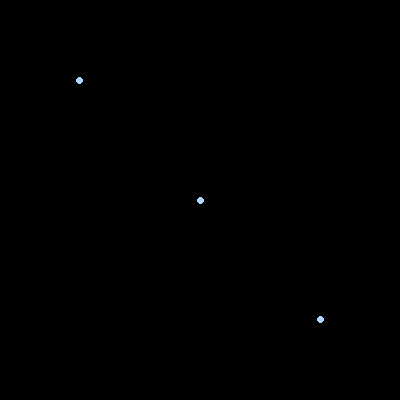

In [14]:
from utils.node import Node
from PIL import Image
from IPython.display import display

node_cases = [
    (124.2, 8.2, 0, True),
    (124.2, 8.2, 1, True),
    (124.2, 8.2, 2, True),
    (124.2, 8.2, 3, True),
    (124.2, 8.2, None, True),
]

for lon, lat, layer, expected in node_cases:
    label = f"Node({lon}, {lat}, {layer})"
    if layer is None:
        validate_call(label, expected, Node, lon, lat)
    else:
        validate_call(label, expected, Node, lon, lat, layer)

for lon, lat, layer in [(124.2, 8.2, 4), (124.2, 8.2, -1)]:
    validate_call(f"Node({lon}, {lat}, {layer})", False, Node, lon, lat, layer)

for lon, lat, layer in [(181, 8.2, 0), (-181, 8.2, 0), (124.2, 91, 0), (124.2, -91, 0)]:
    validate_call(f"Node({lon}, {lat}, {layer})", False, Node, lon, lat, layer)

def verify_node_contract() -> bool:
    n1 = Node(124.2, 8.2, 0)
    n2 = Node(124.2, 8.2, 0)

    assert_true(n1.id != n2.id, "Node IDs should be unique")
    assert_true(isinstance(n1.id, str) and n1.id.startswith("N"), "Node ID should be a string")
    assert_true(n1.lon == 124.2 and n1.lat == 8.2, "Node coordinates should be preserved")

    try:
        n1.lon = 125.0
        raise AssertionError("Node.lon should be immutable")
    except AttributeError:
        pass

    try:
        n1.lat = 9.0
        raise AssertionError("Node.lat should be immutable")
    except AttributeError:
        pass

    return True

validate_call("Node identity and immutability", True, verify_node_contract)

img_node = Image.new("RGB", (400, 400), "black")
context = ((124.20, 8.30), (124.30, 8.20))
for node in [Node(124.22, 8.28, 0), Node(124.28, 8.22, 1), Node(124.25, 8.25, 2)]:
    node.draw(context, img_node)

validate_call("Node visualization square image", True, assert_square_image, img_node)
display(img_node)


## **DirEdge** (in directed_edge.py)

[VALIDATED] DirEdge(Node(N19c7d4a7e2794d6db5c9560a0a069a5f): lon=124.2384, lat=8.2393, layer=1, 
Node(N954da86d9a9044f09c07df1406443dae): lon=124.243862, lat=8.237768, layer=1): Executed successfully.

[REJECTED] DirEdge(None, Node(N954da86d9a9044f09c07df1406443dae): lon=124.243862, lat=8.237768, layer=1): Safely 
blocked with ValueError([DIR EDGE] No start node provided.)

[REJECTED] DirEdge(Node(N19c7d4a7e2794d6db5c9560a0a069a5f): lon=124.2384, lat=8.2393, layer=1, None): Safely 
blocked with ValueError([DIR EDGE] No end node provided.)

[REJECTED] DirEdge(Node(N19c7d4a7e2794d6db5c9560a0a069a5f): lon=124.2384, lat=8.2393, layer=1, 
Node(N19c7d4a7e2794d6db5c9560a0a069a5f): lon=124.2384, lat=8.2393, layer=1): Safely blocked with ValueError([DIR 
EDGE] Start and end nodes cannot be identical.)

[REJECTED] DirEdge(Node(N19c7d4a7e2794d6db5c9560a0a069a5f): lon=124.2384, lat=8.2393, layer=1, 
Node(Nfbbaf3dc000f48b7a5e8d3bfbd28518b): lon=124.243862, lat=8.237768, layer=0): Safely blocked with 
ValueError([DIR EDGE] Start and end nodes on different layers must have same coordinates.)

...

[VALIDATED] DirEdge(Node(N19c7d4a7e2794d6db5c9560a0a069a5f): lon=124.2384, lat=8.2393, layer=1, 
Node(N954da86d9a9044f09c07df1406443dae): lon=124.243862, lat=8.237768, layer=1): Executed successfully.

[VALIDATED] DirEdge type: Executed successfully.

[REJECTED] DirEdge(Node(N8a77929c0026461a87d0e296aeeaf1da): lon=124.2384, lat=8.2393, layer=3, 
Node(N8a77929c0026461a87d0e296aeeaf1da): lon=124.2384, lat=8.2393, layer=3): Safely blocked with ValueError([DIR 
EDGE] Start and end nodes cannot be identical.)

[REJECTED] DirEdge(Node(N19c7d4a7e2794d6db5c9560a0a069a5f): lon=124.2384, lat=8.2393, layer=1, 
Node(Nfbbaf3dc000f48b7a5e8d3bfbd28518b): lon=124.243862, lat=8.237768, layer=0): Safely blocked with 
ValueError([DIR EDGE] Start and end nodes on different layers must have same coordinates.)

[VALIDATED] DirEdge visualization square image: Executed successfully.

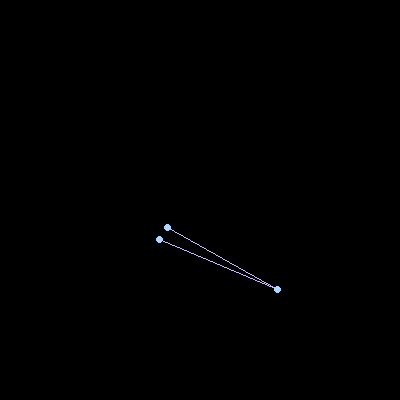

In [15]:
from utils.node import Node
from utils.directed_edge import DirEdge, _stitch
from PIL import Image
from IPython.display import display

n1l1 = Node(124.2384, 8.2393, 1)
n2l1 = Node(124.243862, 8.237768, 1)
n3l1 = Node(124.238, 8.239, 1)
n1l2 = Node(124.2384, 8.2393, 2)
n2l2 = Node(124.243862, 8.237768, 2)
n3l2 = Node(124.238, 8.239, 2)
n1l3 = Node(124.2384, 8.2393, 3)
n2l3 = Node(124.243862, 8.237768, 3)
n3l3 = Node(124.238, 8.239, 3)
n1l0 = Node(124.2384, 8.2393, 0)
n2l0 = Node(124.243862, 8.237768, 0)
n3l0 = Node(124.238, 8.239, 0)

dir_edge_cases = [
    (n1l1, n2l1, True),
    (None, n2l1, False),
    (n1l1, None, False),
    (n1l1, n1l1, False),
    (n1l1, n2l0, False),
]

for start_node, end_node, expected in dir_edge_cases:
    validate_call(f"DirEdge({start_node}, {end_node})", expected, DirEdge, start_node, end_node)

dir_edges_s = [DirEdge(n1l1, n2l1), DirEdge(n2l1, n3l1)]
dir_edges_e = [DirEdge(n1l2, n2l2), DirEdge(n2l1, n2l2)]
validate_call("_stitch(dir_edges_s, dir_edges_e, weight=2)", True, _stitch, dir_edges_s, dir_edges_e, weight=2)
validate_call("Stitched edge connections", True, lambda: [edge.next_edges for edge in dir_edges_s + dir_edges_e])

validate_call("Great-circle distance", True, lambda: DirEdge(n1l1, n2l1).getLength())

for start_node, end_node, expected in [(n1l1, n2l1, True), (n1l3, n1l3, False), (n1l1, n2l0, False)]:
    dir_edge = validate_call(f"DirEdge({start_node}, {end_node})", expected, DirEdge, start_node, end_node)
    if dir_edge is not None:
        validate_call("DirEdge type", True, lambda edge=dir_edge: edge.getType())

img_edge = Image.new("RGB", (400, 400), "black")
context_edge = ((124.230, 8.245), (124.250, 8.235))
for edge in [DirEdge(n1l1, n2l1), DirEdge(n2l1, n3l1)]:
    edge.draw(context_edge, img_edge)
for node in [n1l1, n2l1, n3l1]:
    node.draw(context_edge, img_edge)

validate_call("DirEdge visualization square image", True, assert_square_image, img_edge)
display(img_edge)


## **CityGraph** (in city_graph.py)

[REJECTED] BBOX Validation (Too Short): Safely blocked with ValueError([CITY GRAPH] Invalid bbox. Must be a tuple 
of 4 floats: (min_lat, max_lat, min_lon, max_lon).)

[VALIDATED] CityGraph Instance Creation: Executed successfully.

[VALIDATED] Valid Path A* (n1 -> n3): Executed successfully.

[REJECTED] Orphan Node Exception: Safely blocked with ValueError([CITY GRAPH] Start and end nodes must belong to 
this CityGraph instance.)

[VALIDATED] Visualization Return Type: Executed successfully.

[VALIDATED] Image Aspect Ratio Verification: Executed successfully.

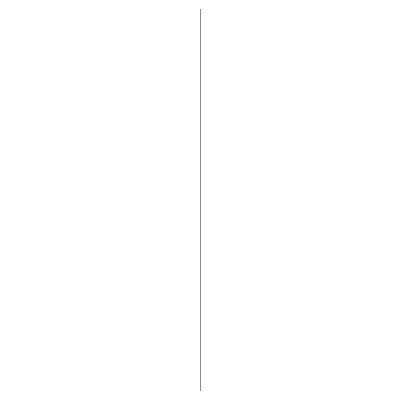

In [16]:
from utils.city_graph import CityGraph
from utils.node import Node
from utils.directed_edge import DirEdge

MOCK_BBOX = (8.22, 8.25, 124.23, 124.26)
LOCAL_PBF_PATH = "utils/data/iligan-city.pbf"

validate_call("BBOX Validation (Too Short)", False, CityGraph, bbox=(8.2,))
cg = validate_call(
    "CityGraph Instance Creation",
    True,
    CityGraph,
    bbox=MOCK_BBOX,
    name="DiagnosticGraph",
    pbf_path=LOCAL_PBF_PATH,
    use_api=False,
)

if cg:
    n1 = Node(124.24, 8.23)
    n2 = Node(124.24, 8.24)
    n3 = Node(124.24, 8.25)
    e1 = DirEdge(n1, n2, is_drivable=True)
    e2 = DirEdge(n2, n3, is_drivable=True)

    cg.nodes = [n1, n2, n3]
    cg.graph = [e1, e2]
    cg.stitch_graph()

    validate_call("Valid Path A* (n1 -> n3)", True, cg.find_shortest_path, n1, n3)
    n_rogue = Node(120.0, 10.0)
    validate_call("Orphan Node Exception", False, cg.find_shortest_path, n1, n_rogue)

    img = validate_call("Visualization Return Type", True, cg.draw, size=400)
    if img:
        validate_call("Image Aspect Ratio Verification", True, assert_square_image, img)
        display(img)

[CITY GRAPH] Loading graph from binary cache.


[CITY GRAPH] Building edges: 100%|██████████| 75761/75761 [00:00<00:00, 152117.37it/s]


[VALIDATED] Iligan CityGraph Initialization: Executed successfully.

[VALIDATED] Iligan CityGraph Visualization: Executed successfully.

[VALIDATED] Iligan CityGraph Square Image: Executed successfully.

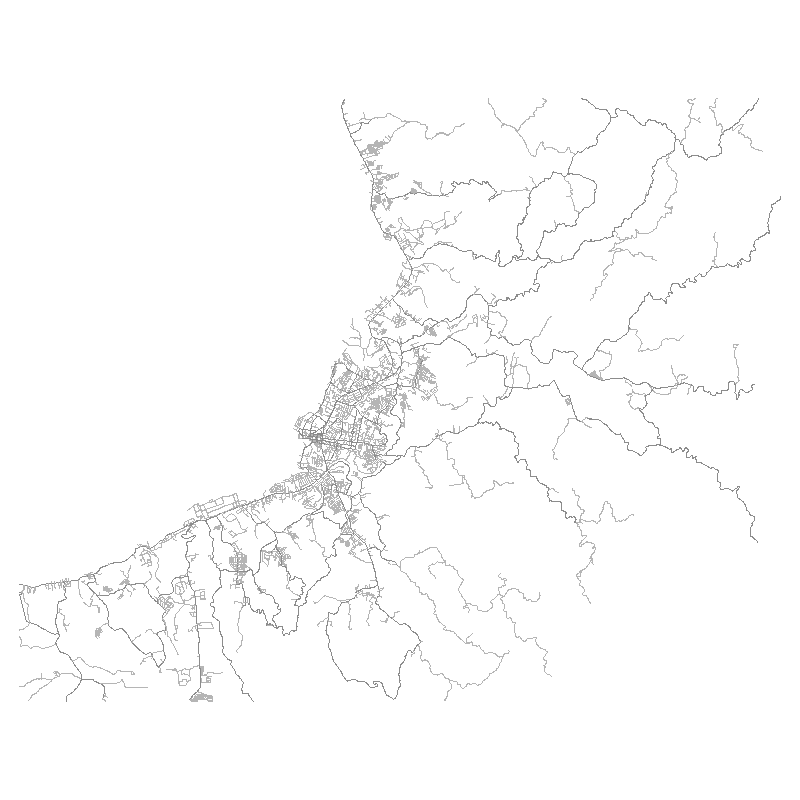

In [17]:
from importlib import reload
from IPython.display import display
import utils.city_graph as city_graph_module

city_graph_module = reload(city_graph_module)
CityGraph = city_graph_module.CityGraph

city_graph_cfg = load_yaml_config("configs/iligan_configs.yaml")["city_graph"]

iligan_city = validate_call(
    "Iligan CityGraph Initialization",
    True,
    CityGraph,
    bbox=tuple(city_graph_cfg["bbox"]),
    name=city_graph_cfg["name"],
    landmarks=city_graph_cfg["landmarks"],
    pbf_path=city_graph_cfg["pbf_path"],
    use_api=False,
    verbose=True,
)

if iligan_city:
    iligan_img = validate_call(
        "Iligan CityGraph Visualization",
        True,
        iligan_city.draw,
        size=800,
        only_drivable=False,
    )

    if iligan_img:
        validate_call("Iligan CityGraph Square Image", True, assert_square_image, iligan_img)
        display(iligan_img)

## **DirectDemandSampler** (in direct_demand_sampler.py)

In [18]:
# prepare .env

import os
from dotenv import load_dotenv

load_dotenv()
TOMTOM_API_KEY = os.getenv("TOMTOM_API_KEY")

if not TOMTOM_API_KEY:
    raise ValueError("[ENVIRONMENT] TOMTOM_API_KEY is missing from the .env file.")
else:
    validate_call("TOMTOM API key present", True, lambda: bool(TOMTOM_API_KEY))

[VALIDATED] TOMTOM API key present: Executed successfully.

In [19]:
# initialize citygraph

from utils.city_graph import CityGraph
from IPython.display import display
from rich import print


full_network_bbox = (8.1500, 8.3300, 124.1500, 124.4000)
explicit_coords = {
    "MSU-IIT": (8.2415, 124.2435),
    "Robinsons Place": (8.2175, 124.2380)
}

city = validate_call(
    "CityGraph initialization", 
    True, 
    CityGraph, 
    bbox=full_network_bbox,
    name="Iligan Full Sector",
    landmarks=explicit_coords,
    pbf_path="utils/data/iligan-city.pbf",
    verbose=True
)

if city:
    validate_call("CityGraph node count", True, lambda: len(city.nodes))


[CITY GRAPH] Loading graph from binary cache.


[CITY GRAPH] Building edges: 100%|██████████| 75761/75761 [00:00<00:00, 115301.40it/s]


[VALIDATED] CityGraph initialization: Executed successfully.

[VALIDATED] CityGraph node count: Executed successfully.

### Spatial Topology and API Token Economy

The base road network is parsed into a directed multi-graph. To execute inverse distance weighting on empirical TomTom traffic data without exhausting API quotas, we calculate a statistically valid sample size dynamically using Cochran's formula.

To achieve a 95% confidence level with a 5% margin of error across the finite population of total network nodes, the initial sample size $n_0$ is calculated as:

$$n_0 = \frac{Z^2 p q}{e^2}$$

Where $Z = 1.96$ (95% confidence level), $p = 0.5$ (maximum population variance), and $e = 0.05$ (5% acceptable margin of error). This yields $n_0 = 384$. 

Applying the finite population correction for the dynamically retrieved node count $N$:

$$n = \frac{n_0}{1 + \frac{n_0 - 1}{N}}$$

The subsequent cell computes this exact value $n$ to restrict the API limits automatically, ensuring representative spatial accuracy while preserving transaction tokens.

*Source:* Cochran, W. G. (1977). *Sampling Techniques* (3rd ed.). John Wiley & Sons.

In [20]:
from utils.city_graph import CityGraph
from utils.direct_demand_sampler import DirectDemandSampler, DDMConfig

cfg = load_yaml_config("configs/iligan_configs.yaml")

city = validate_call(
    "Iligan CityGraph Initialization",
    True,
    CityGraph,
    bbox=tuple(cfg["city_graph"]["bbox"]),
    name=cfg["city_graph"]["name"],
    use_api=False
)


[VALIDATED] Iligan CityGraph Initialization: Executed successfully.

[VALIDATED] CityGraph with All Edges: Executed successfully.

[VALIDATED] CityGraph with Only Drivable Edges: Executed successfully.

All Edges vs. Only Drivable

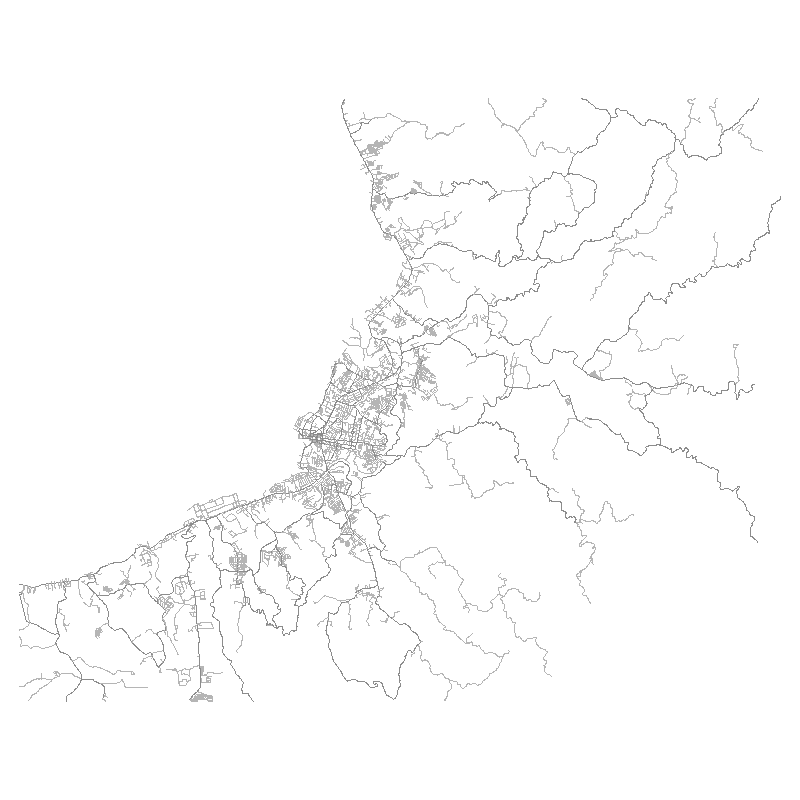

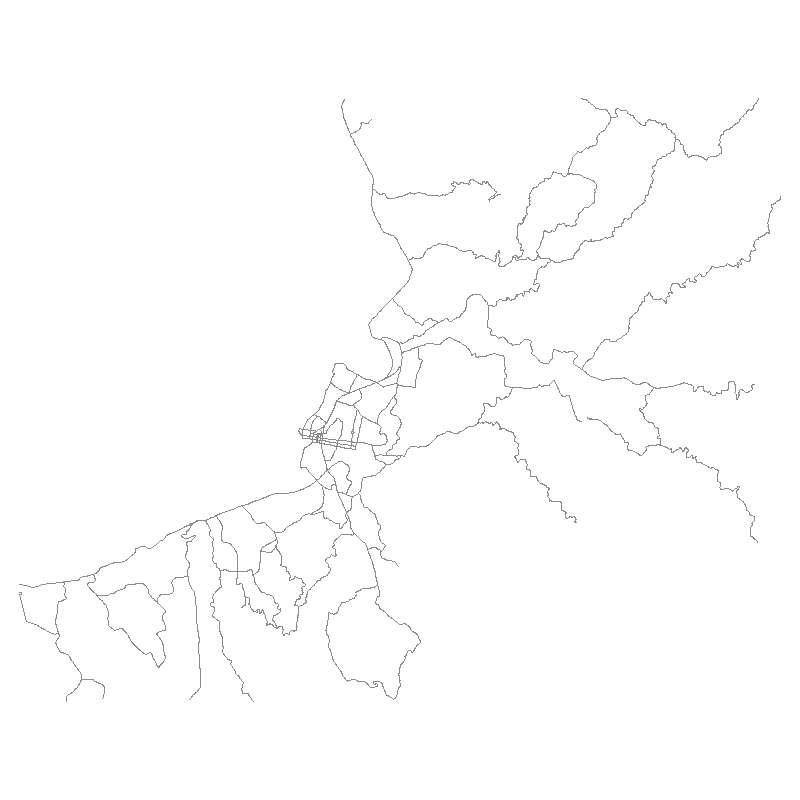

In [21]:
# Compare CityGraph rendering with all edges vs. only drivable edges
if city:
    # Render with all edges
    all_edges_img = validate_call(
        "CityGraph with All Edges",
        True,
        city.draw,
        size=800,
        only_drivable=False
    )
    
    # Render with only drivable edges
    drivable_only_img = validate_call(
        "CityGraph with Only Drivable Edges",
        True,
        city.draw,
        size=800,
        only_drivable=True
    )
    
    # Display both images
    if all_edges_img and drivable_only_img:
        from IPython.display import display
        print("[bold cyan]All Edges vs. Only Drivable[/bold cyan]")
        display(all_edges_img)
        display(drivable_only_img)


## **Route** (in route.py)

In [22]:
import copy
from utils.node import Node
from utils.directed_edge import DirEdge
from utils.route import Route

class MockCityGraph:
    pass

cg = MockCityGraph()

n1 = Node(124.2, 8.2, 2)
n2 = Node(124.3, 8.2, 2)
n3 = Node(124.3, 8.3, 2)
n4 = Node(124.2, 8.3, 2)
n_rogue = Node(0.0, 0.0, 2)

e1 = set_layer(DirEdge(n1, n2, weight=10), 2)
e2 = set_layer(DirEdge(n2, n3, weight=10), 2)
e3 = set_layer(DirEdge(n3, n4, weight=10), 2)
e4 = set_layer(DirEdge(n4, n1, weight=10), 2)
e1.next_edges = [e2]; e2.next_edges = [e3]; e3.next_edges = [e4]; e4.next_edges = [e1]

base_path = [e1, e2, e3, e4]

valid_path = copy.deepcopy(base_path)
open_path = copy.deepcopy(base_path)[:-1]

broken_path = copy.deepcopy(base_path)
broken_path[1] = set_layer(DirEdge(n_rogue, n3, weight=10), 2)

layer_path = copy.deepcopy(base_path)
set_layer(layer_path[2], 1)

branching_path = copy.deepcopy(base_path)
rogue_edge = set_layer(DirEdge(n2, n_rogue, weight=10), 2)
branching_path[0].next_edges.append(rogue_edge)

route_cases = [
    ("Valid Looping Route", True, valid_path),
    ("Open Loop Violation", False, open_path),
    ("Contiguity Violation", False, broken_path),
    ("Layer Restriction Violation", False, layer_path),
    ("Branching Violation", False, branching_path),
]

for label, expected, path in route_cases:
    validate_call(label, expected, Route, cg, path)


[VALIDATED] Valid Looping Route: Executed successfully.

[REJECTED] Open Loop Violation: Safely blocked with ValueError([ROUTE] Path fails to loop. Terminal edge must 
connect to initial edge.)

[REJECTED] Contiguity Violation: Safely blocked with ValueError([ROUTE] Contiguity broken at index 0. Edges do not 
form a continuous sequence.)

[REJECTED] Layer Restriction Violation: Safely blocked with ValueError([ROUTE] Invalid edge layer. Edge 
N3b46b5fd4f074bf0807c0e0058005e3aNed407536a13a4fdea6dae49512e63bfa does not belong strictly to Layer 2.)

[REJECTED] Branching Violation: Safely blocked with ValueError([ROUTE] Branching violation. Edge 
N9c8037cd7d9443b2a32c4ad1e763acbfN974c9a424060442d97eb01d58e0cacf8 must have exactly one outgoing Layer 2 edge. 
Found 2.)

[VALIDATED] Initialize DDM Sampler: Executed successfully.

[VALIDATED] Initialize RouteGenerator: Executed successfully.

[REJECTED] Minimum Points Violation: Safely blocked with ValueError([ROUTE GENERATOR] Minimum of 2 points required 
to generate a route.)

[VALIDATED] Generate Iligan Route (5 points): Executed successfully.

[VALIDATED] Render Iligan Base Map: Executed successfully.

[VALIDATED] Calculate Iligan Bounding Context: Executed successfully.

[VALIDATED] Overlay Proposed Route: Executed successfully.

[VALIDATED] Verify Image Return Type: Executed successfully.

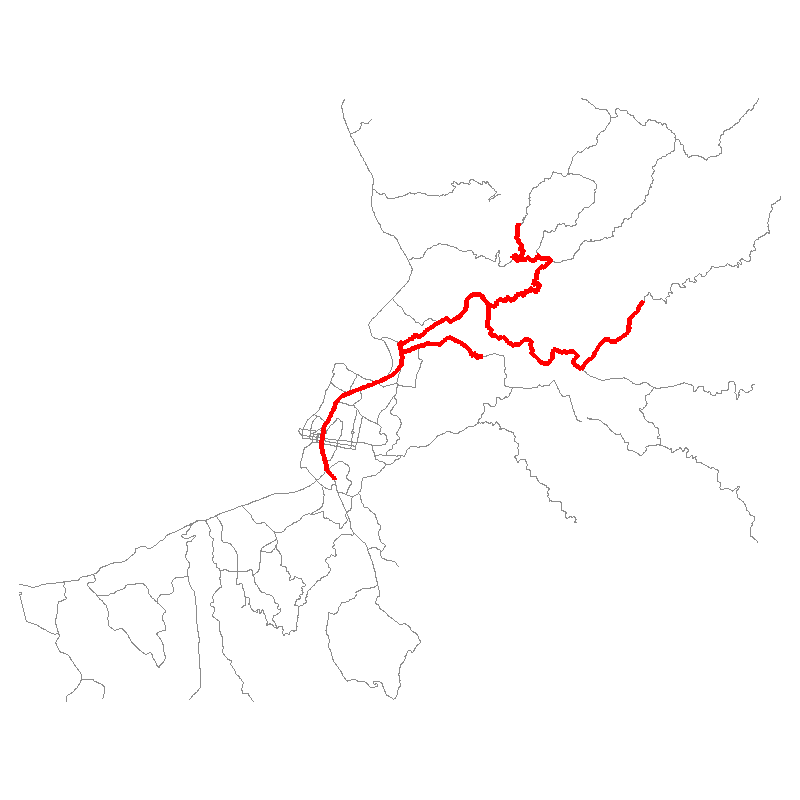

In [23]:
from PIL import Image
from utils.route import RouteGenerator

if cfg:
    if city:
        sampler = validate_call(
            "Initialize DDM Sampler",
            True,
            DirectDemandSampler,
            city=city,
            config=DDMConfig(**cfg["ddm"]),
            only_drivable=True
        )
        
        if sampler:
            generator = validate_call(
                "Initialize RouteGenerator",
                True,
                RouteGenerator,
                city_graph=city,
                sampler=sampler
            )
            
            if generator:
                validate_call("Minimum Points Violation", False, generator.generate, n_points=1)
                route = validate_call("Generate Iligan Route (5 points)", True, generator.generate, n_points=5)
                
                if route:
                    base_img = validate_call("Render Iligan Base Map", True, city.draw, size=800, only_drivable=True)
                    context = validate_call("Calculate Iligan Bounding Context", True, city.get_bounds)
                    
                    if base_img and context:
                        drawn_img = validate_call(
                            "Overlay Proposed Route",
                            True,
                            route.draw,
                            context=context,
                            image=base_img,
                            color="#FF0000",
                            width=4
                        )
                        
                        if drawn_img:
                            validate_call("Verify Image Return Type", True, lambda: assert_true(isinstance(drawn_img, Image.Image), "Expected an Image.Image result."))
                            display(drawn_img)

## **TravelGraph** (in travel_graph.py)


[VALIDATED] Initialize StaticTravelGraph: Executed successfully.

[VALIDATED] STG has base edges: Executed successfully.

[VALIDATED] Initialize TravelGraph: Executed successfully.

[VALIDATED] TravelGraph generated routes: Executed successfully.

[ROUTES] 4 route(s) generated (n_routes=4, n_points=4):

...

Step 05 → END WALK — 🚶 Walking to final destination [210 edges] | 8389.8 m

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[VALIDATED] Journey sequence: if ride used, WA appears before RI: Executed successfully.

[VALIDATED] Journey sequence: if ride used, AL appears after RI: Executed successfully.

[VALIDATED] Journey ends with EW (end walk to destination): Executed successfully.

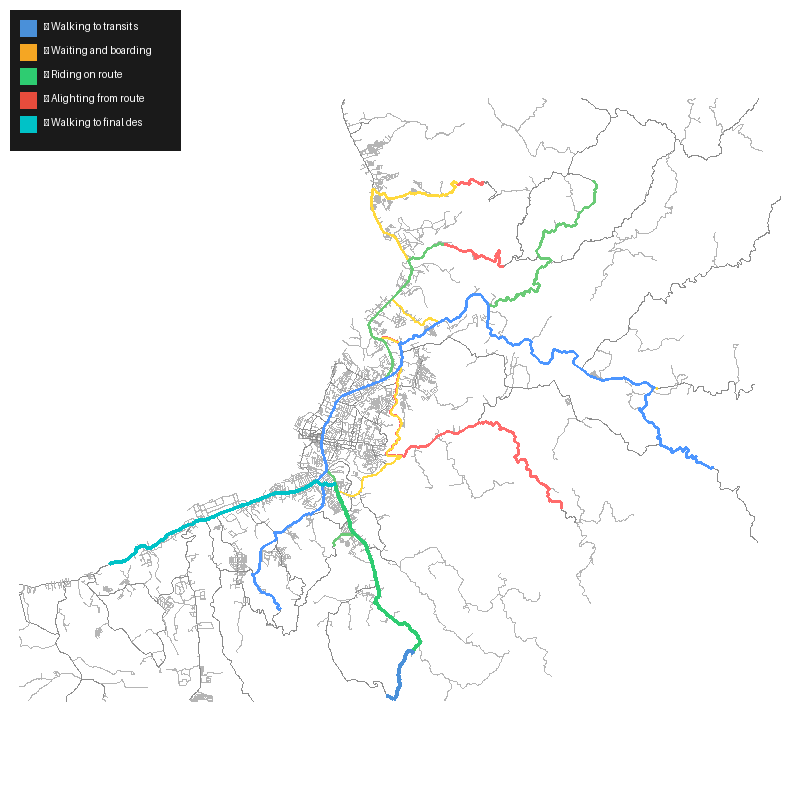

[VALIDATED] Unknown node returns empty list: Executed successfully.

In [ ]:
from utils.travel_graph import StaticTravelGraph, TravelGraph
from IPython.display import display
from PIL import ImageDraw, Image

# ── Configuration ────────────────────────────────────────────────────────────
N_ROUTES  = 1  # number of transit routes to generate
N_POINTS  = 4  # number of waypoints per route

EDGE_COLORS = {
    "SW": "#4A90D9",
    "EW": "#00C2C7",
    "DI": "#A0A0A0",
    "WA": "#F5A623",
    "RI": "#2ECC71",
    "AL": "#E74C3C",
    "TR": "#9B59B6",
}

EDGE_LABELS = {
    "SW": ("[bold blue]START WALK[/bold blue]",     "🚶 Walking to transit stop"),
    "DI": ("[bold white]DIRECT WALK[/bold white]", "🚶 Walking directly (no transit used)"),
    "WA": ("[bold yellow]WAIT / BOARD[/bold yellow]", "🕐 Waiting and boarding"),
    "RI": ("[bold green]RIDE[/bold green]",           "🚌 Riding on route"),
    "AL": ("[bold red]ALIGHT[/bold red]",             "🔴 Alighting from route"),
    "TR": ("[bold magenta]TRANSFER[/bold magenta]",   "🔄 Transferring to another route"),
    "EW": ("[bold cyan]END WALK[/bold cyan]",         "🚶 Walking to final destination"),
}

ROUTE_PALETTE = ["#FF6B6B", "#FFD93D", "#6BCB77", "#4D96FF", "#C77DFF"]

if city:
    # ── StaticTravelGraph ────────────────────────────────────────────────────
    stg = validate_call(
        "Initialize StaticTravelGraph",
        True, StaticTravelGraph, cg=city
    )

    if stg:
        validate_call(
            "STG has base edges", True,
            assert_true, len(stg.base_edges) > 0,
            "StaticTravelGraph has no base edges."
        )

        if cfg and sampler and generator:
            # ── TravelGraph construction ──────────────────────────────────────
            tg = validate_call(
                "Initialize TravelGraph",
                True, TravelGraph,
                stg=stg,
                route_generator=generator,
                n_routes=N_ROUTES,
                n_points=N_POINTS
            )

            if tg:
                # ── Route generation ─────────────────────────────────────────
                validate_call(
                    "TravelGraph generated routes", True,
                    assert_true, len(tg.routes) > 0,
                    "TravelGraph has no routes."
                )

                print(f"[bold yellow][ROUTES] {len(tg.routes)} route(s) generated (n_routes={N_ROUTES}, n_points={N_POINTS}):[/bold yellow]")
                for r in tg.routes:
                    n_stops = len({(e.start.lon, e.start.lat) for e in r.path})
                    validate_call(
                        f"Route '{r.id}' has a valid string ID", True,
                        assert_true, isinstance(r.id, str) and r.id.startswith("R"),
                        f"Route ID '{r.id}' is not in expected 'R<n>' format."
                    )
                    print(f"  [bold white]Route {r.id}[/bold white] — {len(r.path)} edges, ~{n_stops} unique stops, color={r.designated_color}")

                # ── Edge-type presence ───────────────────────────────────────
                edge_prefixes = {e.id[:2] for e in tg.travel_graph}
                for prefix in ["SW", "EW", "DI", "WA", "RI", "AL", "TR"]:
                    validate_call(
                        f"Edge type '{prefix}' present in travel graph", True,
                        assert_true, prefix in edge_prefixes,
                        f"No '{prefix}' edges found in travel graph."
                    )

                # ── RI edges encode route index ───────────────────────────────
                ri_edges = [e for e in tg.travel_graph if e.id.startswith("RI_")]
                validate_call(
                    "RI edges encode route ID (RI_R<n>_<seq>)", True,
                    assert_true,
                    all(e.id.split("_")[1].startswith("R") for e in ri_edges),
                    "Some RI edges are missing their encoded route ID."
                )

                # ── Journey query ────────────────────────────────────────────
                start_node = city.nodes[0]
                end_node   = city.nodes[-1]

                print(f"[bold yellow][JOURNEY] Start: lon={start_node.lon:.6f}, lat={start_node.lat:.6f}[/bold yellow]")
                print(f"[bold yellow][JOURNEY] End:   lon={end_node.lon:.6f},   lat={end_node.lat:.6f}[/bold yellow]")

                journey = validate_call(
                    "findShortestJourney returns a path", True,
                    tg.findShortestJourney, start_node, end_node
                )
                validate_call(
                    "calculateJourneyDistance returns positive float", True,
                    assert_true, tg.calculateJourneyDistance(start_node, end_node) > 0,
                    "Journey distance is zero or negative."
                )
                validate_call(
                    "calculateJourneyWeight returns positive float", True,
                    assert_true, tg.calculateJourneyWeight(start_node, end_node) > 0,
                    "Journey weight is zero or negative."
                )

                # ── Journey breakdown ────────────────────────────────────────
                if journey:
                    print("\n[bold white]━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━[/bold white]")
                    print("[bold white]         JOURNEY SEQUENCE BREAKDOWN[/bold white]")
                    print("[bold white]━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━[/bold white]")
                    print(f"[bold white]  Origin    → ({start_node.lon:.5f}, {start_node.lat:.5f})[/bold white]")
                    print(f"[bold white]  Dest      → ({end_node.lon:.5f}, {end_node.lat:.5f})[/bold white]")
                    print(f"[bold white]  Edges     → {len(journey)} total[/bold white]")
                    print("[bold white]━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━[/bold white]")

                    # group consecutive same-type + same-route edges into segments
                    segments = []
                    for edge in journey:
                        prefix = edge.id[:2]
                        route_id = None
                        if prefix == "RI":
                            parts = edge.id.split("_")
                            if len(parts) >= 2:
                                route_id = parts[1]   # e.g. "R0"
                        if segments and segments[-1][0] == prefix and segments[-1][1] == route_id:
                            segments[-1][2].append(edge)
                        else:
                            segments.append([prefix, route_id, [edge]])

                    for step, (prefix, route_id, edges) in enumerate(segments, start=1):
                        label, desc = EDGE_LABELS.get(prefix, (f"[bold]{prefix}[/bold]", "Unknown edge type"))
                        dist = sum(e.getLength() for e in edges) if prefix in {"SW", "EW", "RI"} else 0
                        dist_tag   = f" | {dist:.1f} m" if dist > 0 else ""
                        n_edges    = len(edges)
                        count_tag  = f" [{n_edges} edge{'s' if n_edges != 1 else ''}]"
                        if route_id:
                            route_tag = f" [bold white](Route {route_id})[/bold white]"
                        else:
                            route_tag = ""
                        print(f"  [bold white]Step {step:02d}[/bold white] → {label}{route_tag} — {desc}{count_tag}{dist_tag}")

                    print("[bold white]━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━[/bold white]\n")

                    # ── Journey sequence sanity check ─────────────────────────
                    seg_prefixes = [s[0] for s in segments]
                    has_ride     = "RI" in seg_prefixes
                    validate_call(
                        "Journey sequence: if ride used, WA appears before RI", True,
                        assert_true,
                        (not has_ride) or (seg_prefixes.index("WA") < seg_prefixes.index("RI")),
                        "WA (Wait/Board) must come before RI (Ride) in the journey sequence."
                    )
                    validate_call(
                        "Journey sequence: if ride used, AL appears after RI", True,
                        assert_true,
                        (not has_ride) or (seg_prefixes.index("AL") > seg_prefixes.index("RI")),
                        "AL (Alight) must come after RI (Ride) in the journey sequence."
                    )
                    validate_call(
                        "Journey ends with EW (end walk to destination)", True,
                        assert_true,
                        seg_prefixes[-1] == "EW",
                        f"Journey should end with EW (end walk), but ends with '{seg_prefixes[-1]}'."
                    )

                    # ── Journey visualisation ─────────────────────────────────
                    base_img = city.draw(size=800, only_drivable=False)
                    context  = city.get_bounds()

                    if base_img and context:
                        journey_img = base_img.copy()

                        # draw all routes as thin background lanes
                        for r_idx, route in enumerate(tg.routes):
                            route_color = ROUTE_PALETTE[r_idx % len(ROUTE_PALETTE)]
                            for edge in route.path:
                                edge.draw(context, journey_img, color=route_color, width=2)

                        # overlay the actual journey edges, thicker
                        for edge in journey:
                            prefix = edge.id[:2]
                            color  = EDGE_COLORS.get(prefix, "#FFFFFF")
                            edge.draw(context, journey_img, color=color, width=4)

                        # draw a legend
                        draw        = ImageDraw.Draw(journey_img)
                        BOX         = 16
                        PAD         = 10
                        LH          = 24
                        lx, ly      = 10, 10
                        seen        = {e.id[:2] for e in journey}
                        active      = {k: v for k, v in EDGE_LABELS.items() if k in seen}
                        legend_h    = PAD * 2 + len(active) * LH
                        draw.rectangle([lx, ly, lx + 170, ly + legend_h], fill="#1A1A1A")
                        for i, (prefix, (_, plain_desc)) in enumerate(active.items()):
                            # strip rich markup for PIL text
                            import re
                            clean = re.sub(r"\[.*?\]", "", plain_desc).strip()
                            y = ly + PAD + i * LH
                            draw.rectangle([lx + PAD, y, lx + PAD + BOX, y + BOX], fill=EDGE_COLORS[prefix])
                            draw.text((lx + PAD + BOX + 8, y), clean[:22], fill="#FFFFFF")

                        display(journey_img)

                # ── Edge case: unknown node ───────────────────────────────────
                from utils.node import Node
                ghost_node = Node(0.0, 0.0)
                validate_call(
                    "Unknown node returns empty list", True,
                    assert_true,
                    tg.findShortestJourney(ghost_node, end_node) == [],
                    "Expected empty list for unknown node."
                )
